In [ ]:
%pip install requests pandas scikit-learn matplotlib python-dotenv

# Projekt 21: Wyszukiwanie podobieństw pogody

Celem projektu jest analiza danych pogodowych i znalezienie dni o najbardziej zbliżonych warunkach atmosferycznych do wybranego dnia wzorcowego. Projekt składa się z pięciu etapów: pozyskiwania danych, przetwarzania, normalizacji, analizy podobieństwa oraz wizualizacji.

## 1. Pozyskiwanie danych
Pobieramy surowe dane z REST API i zapisujemy je do lokalnego pliku JSON. Dzięki temu mamy trwałą kopię danych źródłowych przed przystąpieniem do jakichkolwiek przekształceń.

In [3]:
import requests
import json
import os
from datetime import datetime
from dotenv import load_dotenv

load_dotenv()

# API
API_URL = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev/weather/batch"
STATION_ID = "GDN_01"
LIMIT = 500
TOKEN = os.getenv("API_TOKEN")

headers = {"Authorization": TOKEN}
params = {"station_id": STATION_ID, "limit": LIMIT}

response = requests.get(API_URL, headers=headers, params=params)

if response.status_code == 200:
    data = response.json()

    # save data
    os.makedirs("raw_data", exist_ok=True)
    filename = f"raw_data/gdn_01_batch_{datetime.now().strftime('%Y%m%d')}.json"

    with open(filename, "w") as f:
        json.dump(data, f)
    print(f"Data path: {filename}")

else:
    print(f"API error: {response.status_code}")
    print(response.text)
    exit()

Data path: raw_data/gdn_01_batch_20260628.json


## 2. Przetwarzanie danych
Aby móc porównać ze sobą poszczególne dni, agregujemy dane do formatu dziennego, wyliczając wartości średnie, maksymalne oraz sumy dla każdego dnia.
Użyte cechy to:
- Średnia temperatura
- Najnizsza temperatura
- Najwyższa temperatura
- Średnia wilgotność
- Najwyższa prędkość wiatru
- Średnie ciśnienie atmosferyczne
- Łączna ilość opadów
- Średnie zachmurzenie

In [9]:
import pandas as pd

with open(filename, "r") as f:
    raw_json = json.load(f)

df = pd.DataFrame(raw_json["records"])

df['date'] = pd.to_datetime(df['timestamp']).dt.strftime('%Y-%m-%d')

daily_df = df.groupby('date').agg(
    avg_temp=('temperature', 'mean'),
    max_temp=('temperature', 'max'),
    min_temp=('temperature', 'min'),
    avg_humidity=('humidity', 'mean'),
    max_wind=('wind_speed', 'max'),
    avg_pressure=('pressure', 'mean'),
    total_rain=('rain_mm', 'sum'),
    avg_clouds=('cloud_cover', 'mean')
).reset_index()

date_start = daily_df['date'].min()
date_end = daily_df['date'].max()
print(f"Days from {date_start} to {date_end}")

Days from 2026-06-25 to 2026-06-28


## 3. Cechy i normalizacja
Cechy mają różne jednostki i skale. Aby uniknąć dominacji jednej zmiennej nad innymi podczas obliczania odległości, stosujemy normalizację, która sprowadza dane do wspólnej skali o średniej 0 i odchyleniu standardowym 1.

In [10]:
from sklearn.preprocessing import StandardScaler

features = [
    'avg_temp', 'max_temp', 'min_temp',
    'avg_humidity', 'max_wind',
    'avg_pressure', 'total_rain',
    'avg_clouds'
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(daily_df[features])

daily_df['scaled_features'] = list(scaled_features)

print("Example features vector:")
print(daily_df['scaled_features'].iloc[0])

Example features vector:
[-6.56424769e-02 -1.55501304e+00 -5.76326262e-14 -2.63008401e-01
  6.54653671e-01 -8.29087274e-02 -1.34972129e+00  1.13016707e+00]


## 4. Analiza podobieństwa
W tym kroku wybieramy dzień referencyjny i obliczamy odległość euklidesową pomiędzy jego wektorem cech a wektorami wszystkich pozostałych dni w zbiorze. Im mniejsza wartość odległości, tym bardziej zbliżone warunki pogodowe panowały w danym dniu.

In [11]:
from sklearn.metrics.pairwise import euclidean_distances

reference_date = '2026-06-27'

ref_vector = daily_df.loc[daily_df['date'] == reference_date, 'scaled_features'].values[0]
distances = euclidean_distances([ref_vector], list(daily_df['scaled_features']))[0]
daily_df['distance'] = distances
search_results = daily_df[daily_df['date'] != reference_date].copy()
top_similar = search_results.sort_values('distance').head(3)

print(f"3 the most similar days to {reference_date}:\n")
print(top_similar[['date', 'distance', 'avg_temp', 'total_rain']])

3 the most similar days to 2026-06-27:

         date  distance   avg_temp  total_rain
0  2026-06-25  4.741462  17.150935       56.14
3  2026-06-28  5.036261  16.995524       67.17
1  2026-06-26  5.493499  17.120764       89.20


## 5. Prezentacja wyników
Poniższe wykresy wizualizują porównanie dnia wzorcowego z trzema dniami, które algorytm uznał za najbardziej podobne. Pozwala to na szybką weryfikację poprawności działania modelu.

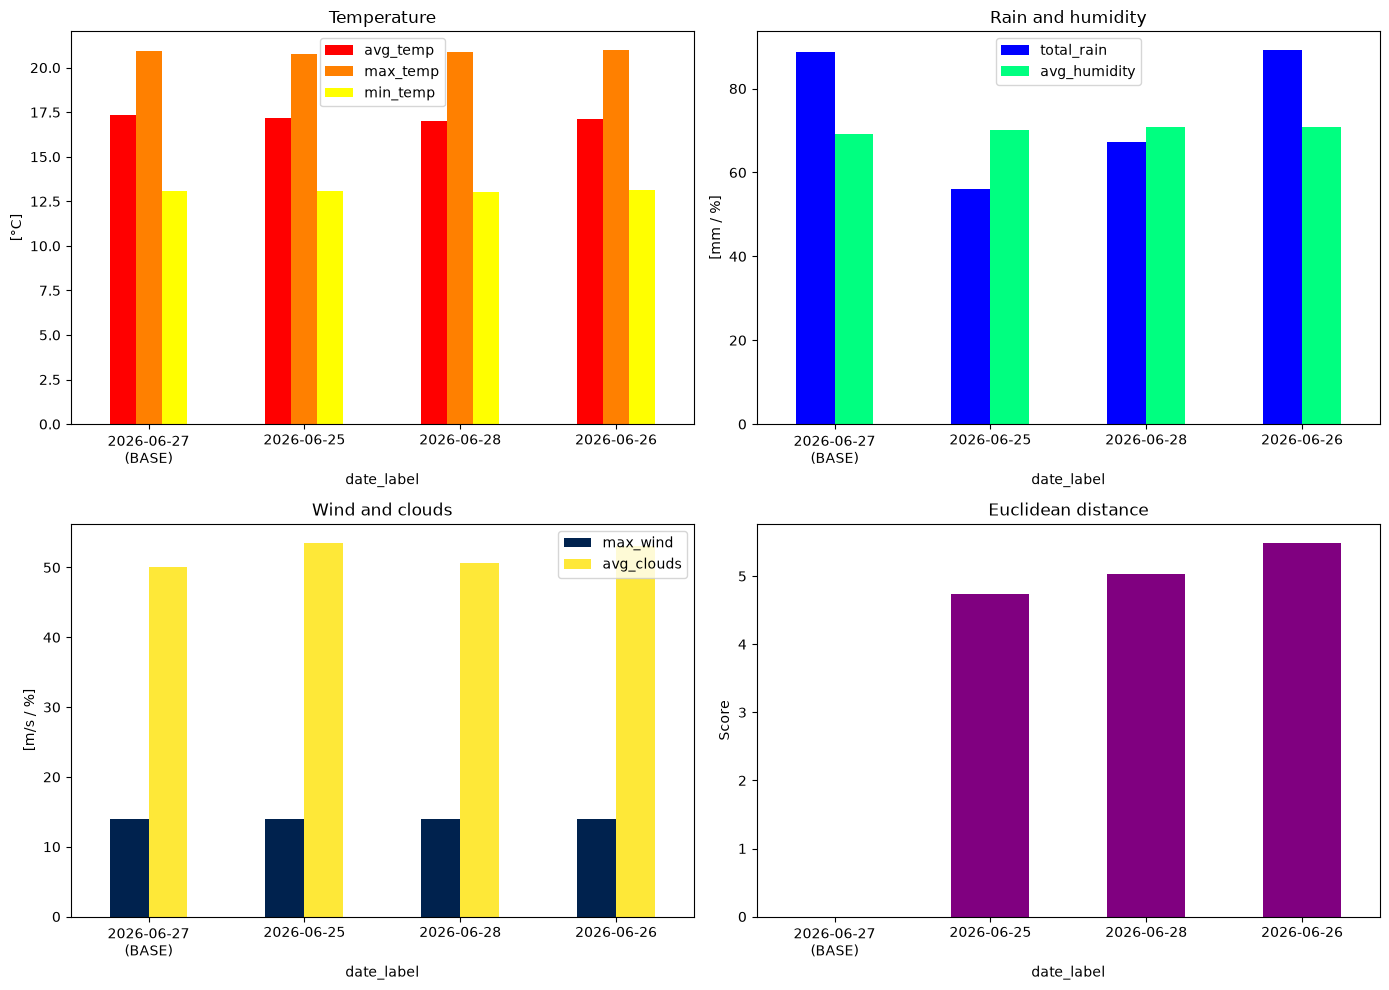

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

ref_row = daily_df[daily_df['date'] == reference_date]
plot_df = pd.concat([ref_row, top_similar]).reset_index(drop=True)

labels = []
for d in plot_df['date']:
    if str(d) == str(reference_date):
        labels.append(str(d) + "\n(BASE)")
    else:
        labels.append(str(d))

plot_df['date_label'] = labels

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_df.plot(x='date_label', y=['avg_temp', 'max_temp', 'min_temp'], kind='bar', ax=axes[0, 0], colormap='autumn')
axes[0, 0].set_title('Temperature')
axes[0, 0].set_ylabel('[°C]')
axes[0, 0].tick_params(axis='x', rotation=0)

plot_df.plot(x='date_label', y=['total_rain', 'avg_humidity'], kind='bar', ax=axes[0, 1], colormap='winter')
axes[0, 1].set_title('Rain and humidity')
axes[0, 1].set_ylabel('[mm / %]')
axes[0, 1].tick_params(axis='x', rotation=0)

plot_df.plot(x='date_label', y=['max_wind', 'avg_clouds'], kind='bar', ax=axes[1, 0], colormap='cividis')
axes[1, 0].set_title('Wind and clouds')
axes[1, 0].set_ylabel('[m/s / %]')
axes[1, 0].tick_params(axis='x', rotation=0)

plot_df.plot(x='date_label', y='distance', kind='bar', ax=axes[1, 1], color='purple', legend=False)
axes[1, 1].set_title('Euclidean distance')
axes[1, 1].set_ylabel('Score')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()